# Road Traffic Sign Recognition — Exploratory Data Analysis

**Student:** Susman
**Course:** TECH 405
**Task:** Exploratory Data Analysis (EDA) — Week Task
**Project type:** Image / Computer Vision (Part A + Part B)

This notebook inspects the traffic-sign dataset provided for this project, performs data-quality
checks, analyzes class distribution and image/bounding-box characteristics, and produces the
visual analyses required for an image classification EDA (sample grids, pixel-intensity
histograms, mean images per class). No model is trained in this notebook — this is EDA only.

> All numbers, tables and plots below are computed directly from the dataset at run time. Nothing
> is hard-coded from a previous run, so re-running this notebook on an updated copy of the dataset
> will automatically refresh every figure and conclusion.


In [1]:
# ---- Imports ----
import ast
import hashlib
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titlesize"] = 11

# ---- Reproducibility ----
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ---- Dataset location (change this if you move the dataset) ----
# This should point at the folder that contains data.yaml plus train/valid/test subfolders.
DATASET_PATH = Path("dataset/car")

assert DATASET_PATH.exists(), f"DATASET_PATH does not exist: {DATASET_PATH.resolve()}"
print("Dataset root:", DATASET_PATH.resolve())


Dataset root: D:\Road Traffic Sign Recognition\dataset\car


## Reusable Helper Functions

All loading, parsing, checking and plotting logic used throughout this notebook is defined once
here as small functions, so the same code is reused consistently across sections instead of being
copy-pasted.


In [2]:
def load_image(path):
    """Safely load an image as a PIL Image. Returns None (and never raises) if the file
    cannot be read, so a single bad file never crashes the notebook."""
    try:
        img = Image.open(path)
        img.load()
        return img
    except Exception:
        return None


def check_corrupt_images(paths):
    """Try to verify every image in `paths`. Returns a list of (path, error_message) for
    files that could not be opened/verified."""
    corrupt = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception as e:
            corrupt.append((p, str(e)))
    return corrupt


def compute_file_hash(path, chunk_size=65536):
    """MD5 hash of a file's raw bytes, used to detect exact duplicate files."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def load_class_names(yaml_path):
    """Minimal parser for the class names / class count out of a YOLO data.yaml file,
    without requiring a PyYAML dependency."""
    text = Path(yaml_path).read_text()
    names, nc = None, None
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("names:"):
            names = ast.literal_eval(line.split("names:", 1)[1].strip())
        elif line.startswith("nc:"):
            nc = int(line.split("nc:", 1)[1].strip())
    return names, nc


def parse_yolo_label(label_path, num_classes=None):
    """Parse one YOLO-format label file (class_id x_center y_center width height, normalized).
    Returns a list of dicts, one per line, each flagged with an `issue` string when the line is
    malformed / out of range, or `issue=None` when the line is valid. Never raises."""
    results = []
    if not Path(label_path).exists():
        return results
    for line_no, raw_line in enumerate(Path(label_path).read_text().splitlines(), start=1):
        line = raw_line.strip()
        if not line:
            continue
        parts = line.split()
        issue, cid, xc, yc, bw, bh = None, None, None, None, None, None
        if len(parts) != 5:
            issue = f"malformed line (expected 5 fields, got {len(parts)})"
        else:
            try:
                cid = int(parts[0])
                xc, yc, bw, bh = (float(v) for v in parts[1:])
            except ValueError:
                issue = "non-numeric field"
        if issue is None:
            if num_classes is not None and not (0 <= cid < num_classes):
                issue = f"class_id {cid} out of range [0,{num_classes - 1}]"
            elif not (0.0 <= xc <= 1.0 and 0.0 <= yc <= 1.0):
                issue = "center coordinate out of [0,1]"
            elif not (0.0 < bw <= 1.0 and 0.0 < bh <= 1.0):
                issue = "non-positive or out-of-range width/height"
        results.append({
            "line_no": line_no, "class_id": cid, "x_center": xc, "y_center": yc,
            "bbox_width": bw, "bbox_height": bh, "issue": issue,
        })
    return results


def yolo_to_pixel_bbox(xc, yc, bw, bh, img_w, img_h):
    """Convert normalized YOLO bbox (center x/y, width, height) to pixel (xmin, ymin, xmax, ymax),
    clipped to the image bounds."""
    xcp, ycp = xc * img_w, yc * img_h
    wp, hp = bw * img_w, bh * img_h
    xmin = max(0, int(round(xcp - wp / 2)))
    ymin = max(0, int(round(ycp - hp / 2)))
    xmax = min(img_w, int(round(xcp + wp / 2)))
    ymax = min(img_h, int(round(ycp + hp / 2)))
    return xmin, ymin, xmax, ymax


def crop_instance(image_path, xc, yc, bw, bh, img_w=None, img_h=None):
    """Load `image_path` and crop out the region described by a normalized YOLO bbox.
    Returns a PIL Image (RGB) or None if the image can't be loaded or the box is degenerate."""
    img = load_image(image_path)
    if img is None:
        return None
    if img_w is None or img_h is None:
        img_w, img_h = img.size
    xmin, ymin, xmax, ymax = yolo_to_pixel_bbox(xc, yc, bw, bh, img_w, img_h)
    if xmax <= xmin or ymax <= ymin:
        return None
    return img.convert("RGB").crop((xmin, ymin, xmax, ymax))


def get_folder_size_mb(path):
    """Total size in MB of all files under `path` (recursive)."""
    total = sum(f.stat().st_size for f in Path(path).rglob("*") if f.is_file())
    return total / (1024 ** 2)


def print_tree(root, max_depth=3, max_files_shown=3):
    """Print a folder/file tree, summarizing large folders instead of listing every file."""
    root = Path(root)

    def _walk(dir_path, prefix="", depth=0):
        if depth > max_depth:
            return
        entries = sorted(dir_path.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
        dirs = [e for e in entries if e.is_dir()]
        files = [e for e in entries if e.is_file()]
        for d in dirs:
            print(f"{prefix}{d.name}/")
            _walk(d, prefix + "    ", depth + 1)
        for f in files[:max_files_shown]:
            print(f"{prefix}{f.name}")
        if len(files) > max_files_shown:
            print(f"{prefix}... ({len(files)} files total)")

    print(f"{root.name}/")
    _walk(root, "    ", 1)


def analyze_image_dimensions(size_pairs):
    """size_pairs: iterable of (width, height). Returns a DataFrame with width, height and
    aspect_ratio columns for downstream statistics/plots."""
    df = pd.DataFrame(list(size_pairs), columns=["width", "height"])
    df["aspect_ratio"] = df["width"] / df["height"]
    return df


def plot_class_distribution(counts, title="Class Distribution", xlabel="Class",
                             ylabel="Count", figsize=(12, 6), color="steelblue"):
    """Bar chart of a pandas Series indexed by class name."""
    fig, ax = plt.subplots(figsize=figsize)
    counts.sort_values(ascending=False).plot(kind="bar", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_sample_grid(images, titles, ncols=5, figsize=None, suptitle=None, cmap=None):
    """Plot a list of PIL/array images in a grid with per-image titles."""
    n = len(images)
    if n == 0:
        print("Nothing to plot.")
        return
    nrows = math.ceil(n / ncols)
    if figsize is None:
        figsize = (3 * ncols, 3 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(images[i], cmap=cmap)
            ax.set_title(titles[i], fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


print("Helper functions defined.")


Helper functions defined.


# Part A — Everyone

## 1. Dataset Card

The facts below were confirmed from the files shipped with the dataset itself
(`data.yaml`, `README.dataset.txt`, `README.roboflow.txt`) and from directly inspecting the
files on disk. Anything not stated in those sources is reported as *"Not available from the
dataset"* rather than guessed.


In [3]:
class_names, nc_declared = load_class_names(DATASET_PATH / "data.yaml")

dataset_card = {
    "Dataset name": "Self-Driving Cars (traffic-light & speed-limit-sign detection export), "
                     "v6 / Version 4 - Prescan - 416x416",
    "Source / link": "https://universe.roboflow.com/selfdriving-car-qtywx/self-driving-cars-lfjou/dataset/6 "
                      "(Roboflow Universe, workspace 'selfdriving-car-qtywx', project 'self-driving-cars-lfjou')",
    "License": "CC BY 4.0 (stated in data.yaml and README.dataset.txt)",
    "Annotation format": "YOLOv8 object-detection format (class_id x_center y_center width height, normalized)",
    "How the data was collected": "Not available from the dataset. The README only states it was "
                                   "'provided by a Roboflow user' and exported via roboflow.com on "
                                   "2023-10-20. The title includes the word 'Prescan', which may hint at "
                                   "a driving-simulation origin, but this is not confirmed anywhere in the "
                                   "dataset documentation, so it is NOT treated as a fact here.",
    "Declared pre-processing": "Images were resized to 416x416 (stretch) by Roboflow before export; "
                                "no image augmentation was applied (per README.roboflow.txt).",
}

for k, v in dataset_card.items():
    print(f"{k}:\n    {v}\n")

print("Declared number of classes (data.yaml 'nc'):", nc_declared)
print("Declared class names (data.yaml 'names'):")
for i, name in enumerate(class_names):
    print(f"  {i:2d} -> {name}")


Dataset name:
    Self-Driving Cars (traffic-light & speed-limit-sign detection export), v6 / Version 4 - Prescan - 416x416

Source / link:
    https://universe.roboflow.com/selfdriving-car-qtywx/self-driving-cars-lfjou/dataset/6 (Roboflow Universe, workspace 'selfdriving-car-qtywx', project 'self-driving-cars-lfjou')

License:
    CC BY 4.0 (stated in data.yaml and README.dataset.txt)

Annotation format:
    YOLOv8 object-detection format (class_id x_center y_center width height, normalized)

How the data was collected:
    Not available from the dataset. The README only states it was 'provided by a Roboflow user' and exported via roboflow.com on 2023-10-20. The title includes the word 'Prescan', which may hint at a driving-simulation origin, but this is not confirmed anywhere in the dataset documentation, so it is NOT treated as a fact here.

Declared pre-processing:
    Images were resized to 416x416 (stretch) by Roboflow before export; no image augmentation was applied (per README.

In [4]:
# ---- Facts computed directly from the files on disk (not from documentation) ----
splits = ["train", "valid", "test"]
image_counts, label_counts = {}, {}
for split in splits:
    image_counts[split] = len(list((DATASET_PATH / split / "images").glob("*")))
    label_counts[split] = len(list((DATASET_PATH / split / "labels").glob("*")))

total_images = sum(image_counts.values())
dataset_size_mb = get_folder_size_mb(DATASET_PATH)

print("Images per split:", image_counts)
print("Label files per split:", label_counts)
print(f"Total images on disk: {total_images}")
print(f"Dataset size on disk ('{DATASET_PATH}' folder): {dataset_size_mb:.2f} MB")

extra_files = [p.name for p in DATASET_PATH.parent.iterdir() if p.is_file()]
if extra_files:
    print(f"\nNote: {DATASET_PATH.parent} also contains non-dataset file(s) not part of the "
          f"annotated image set: {extra_files}. These are excluded from this EDA.")


Images per split: {'train': 3530, 'valid': 801, 'test': 638}
Label files per split: {'train': 3530, 'valid': 801, 'test': 638}
Total images on disk: 4969
Dataset size on disk ('dataset\car' folder): 96.17 MB

Note: dataset also contains non-dataset file(s) not part of the annotated image set: ['video.mp4']. These are excluded from this EDA.


**Image / file structure (as found on disk):**

```
dataset/car/
    data.yaml              -> class list + relative paths used by YOLO training tools
    README.dataset.txt     -> Roboflow export info (license, source)
    README.roboflow.txt    -> Roboflow export info (pre-processing, image count)
    train/images/*.jpg     -> training images
    train/labels/*.txt     -> one YOLO label file per training image (same filename stem)
    valid/images/*.jpg     -> validation images
    valid/labels/*.txt     -> one YOLO label file per validation image
    test/images/*.jpg      -> test images
    test/labels/*.txt      -> one YOLO label file per test image
```

**Known limitations / important assumptions:**

* This is an **object-detection** dataset (one or more bounding boxes per image, each with a
  class id), **not** a folder-per-class classification dataset. An image can contain more than
  one sign/light, and several different classes can appear in the same image.
* Because of that, for the classification-style analyses required by this assignment (class
  distribution, sample grids, pixel histograms, mean image per class), each **annotated bounding
  box is treated as one labeled sample** (cropped out of its parent image). This is a deliberate,
  clearly-stated design decision for this notebook, not a property of the raw dataset.
* Images were already resized to a fixed 416x416 by Roboflow before export, so the *original*
  camera/source resolution is not recoverable from this dataset.
* License is CC BY 4.0 — attribution to the source is required for any reuse.


## 2. Load the Dataset

The cell below auto-detects the dataset layout under `DATASET_PATH` (it does not assume a
particular structure ahead of time), then builds two tidy tables:

* `images_df` — one row per image (split, path, pixel size, color mode, number of annotated objects)
* `instances_df` — one row per **annotated bounding box** (its class, normalized and pixel
  coordinates, and whether the label line was valid)


In [5]:
print("Detected dataset structure under", DATASET_PATH.resolve())
print_tree(DATASET_PATH, max_depth=2)


Detected dataset structure under D:\Road Traffic Sign Recognition\dataset\car
car/
    test/
        images/
        labels/
    train/
        images/
        labels/
    valid/
        images/
        labels/
    data.yaml
    README.dataset.txt
    README.roboflow.txt


In [6]:
def scan_split(split, num_classes):
    images_dir = DATASET_PATH / split / "images"
    labels_dir = DATASET_PATH / split / "labels"
    img_rows, inst_rows = [], []

    for img_path in sorted(images_dir.glob("*")):
        label_path = labels_dir / (img_path.stem + ".txt")
        img = load_image(img_path)
        width = height = mode = None
        if img is not None:
            width, height = img.size
            mode = img.mode

        parsed = parse_yolo_label(label_path, num_classes=num_classes) if label_path.exists() else []
        valid_parsed = [p for p in parsed if p["issue"] is None]

        img_rows.append({
            "split": split,
            "image_path": str(img_path),
            "filename": img_path.name,
            "extension": img_path.suffix.lower(),
            "label_path": str(label_path),
            "has_label_file": label_path.exists(),
            "width": width,
            "height": height,
            "mode": mode,
            "load_ok": img is not None,
            "num_objects_total": len(parsed),
            "num_objects_valid": len(valid_parsed),
        })

        for p in parsed:
            bbox_w_px = bbox_h_px = None
            class_name = None
            if p["issue"] is None and width and height:
                bbox_w_px = p["bbox_width"] * width
                bbox_h_px = p["bbox_height"] * height
                class_name = class_names[p["class_id"]]
            inst_rows.append({
                "split": split,
                "image_path": str(img_path),
                "label_path": str(label_path),
                "line_no": p["line_no"],
                "class_id": p["class_id"],
                "class_name": class_name,
                "x_center": p["x_center"],
                "y_center": p["y_center"],
                "bbox_width": p["bbox_width"],
                "bbox_height": p["bbox_height"],
                "bbox_width_px": bbox_w_px,
                "bbox_height_px": bbox_h_px,
                "img_width": width,
                "img_height": height,
                "issue": p["issue"],
            })

    return img_rows, inst_rows


all_img_rows, all_inst_rows = [], []
for split in splits:
    ir, ins = scan_split(split, num_classes=nc_declared)
    all_img_rows.extend(ir)
    all_inst_rows.extend(ins)

images_df = pd.DataFrame(all_img_rows)
instances_df = pd.DataFrame(all_inst_rows)

print("images_df shape   :", images_df.shape)
print("instances_df shape:", instances_df.shape)
images_df.head()


images_df shape   : (4969, 12)
instances_df shape: (6012, 15)


,split,image_path,filename,extension,label_path,has_label_file,width,height,mode,load_ok,num_objects_total,num_objects_valid
0,train,dataset\car\train\images\000000_jpg.rf.b11f308...,000000_jpg.rf.b11f308f16626f9f795a148029c46d10...,.jpg,dataset\car\train\labels\000000_jpg.rf.b11f308...,True,416,416,RGB,True,1,1
1,train,dataset\car\train\images\000005_jpg.rf.d730849...,000005_jpg.rf.d730849ae93a7c211a7c8f57ed851028...,.jpg,dataset\car\train\labels\000005_jpg.rf.d730849...,True,416,416,RGB,True,1,1
2,train,dataset\car\train\images\000007_jpg.rf.226fe07...,000007_jpg.rf.226fe0751cf8ba445b8f87970e70f606...,.jpg,dataset\car\train\labels\000007_jpg.rf.226fe07...,True,416,416,RGB,True,1,1
3,train,dataset\car\train\images\000008_jpg.rf.bd6ae6d...,000008_jpg.rf.bd6ae6db0f8c0eb727706bc322ce21ae...,.jpg,dataset\car\train\labels\000008_jpg.rf.bd6ae6d...,True,416,416,RGB,True,1,1
4,train,dataset\car\train\images\000009_jpg.rf.df4118d...,000009_jpg.rf.df4118d1d26fa7a25923521216cc2f64...,.jpg,dataset\car\train\labels\000009_jpg.rf.df4118d...,True,416,416,RGB,True,1,1


In [7]:
# Sample of the instance-level table
instances_df.head()


,split,image_path,label_path,line_no,class_id,class_name,x_center,y_center,bbox_width,bbox_height,bbox_width_px,bbox_height_px,img_width,img_height,issue
0,train,dataset\car\train\images\000000_jpg.rf.b11f308...,dataset\car\train\labels\000000_jpg.rf.b11f308...,1,7,Speed Limit 30,0.533654,0.317308,0.169471,0.317308,70.5,132.0,416,416,None
1,train,dataset\car\train\images\000005_jpg.rf.d730849...,dataset\car\train\labels\000005_jpg.rf.d730849...,1,7,Speed Limit 30,0.576923,0.360577,0.415865,0.275240,173.0,114.5,416,416,None
2,train,dataset\car\train\images\000007_jpg.rf.226fe07...,dataset\car\train\labels\000007_jpg.rf.226fe07...,1,7,Speed Limit 30,0.518029,0.485577,0.622596,0.450721,259.0,187.5,416,416,None
3,train,dataset\car\train\images\000008_jpg.rf.bd6ae6d...,dataset\car\train\labels\000008_jpg.rf.bd6ae6d...,1,7,Speed Limit 30,0.486779,0.436298,0.439904,0.289663,183.0,120.5,416,416,None
4,train,dataset\car\train\images\000009_jpg.rf.df4118d...,dataset\car\train\labels\000009_jpg.rf.df4118d...,1,7,Speed Limit 30,0.317308,0.534856,0.402644,0.596154,167.5,248.0,416,416,None


In [8]:
# Image data types / array shape for a sample image
sample_path = images_df.loc[images_df["load_ok"], "image_path"].iloc[0]
sample_img = load_image(sample_path)
sample_arr = np.array(sample_img)
print("Sample file:", sample_path)
print("PIL mode   :", sample_img.mode, " size:", sample_img.size)
print("NumPy dtype:", sample_arr.dtype, " array shape:", sample_arr.shape)


Sample file: dataset\car\train\images\000000_jpg.rf.b11f308f16626f9f795a148029c46d10.jpg
PIL mode   : RGB  size: (416, 416)
NumPy dtype: uint8  array shape: (416, 416, 3)


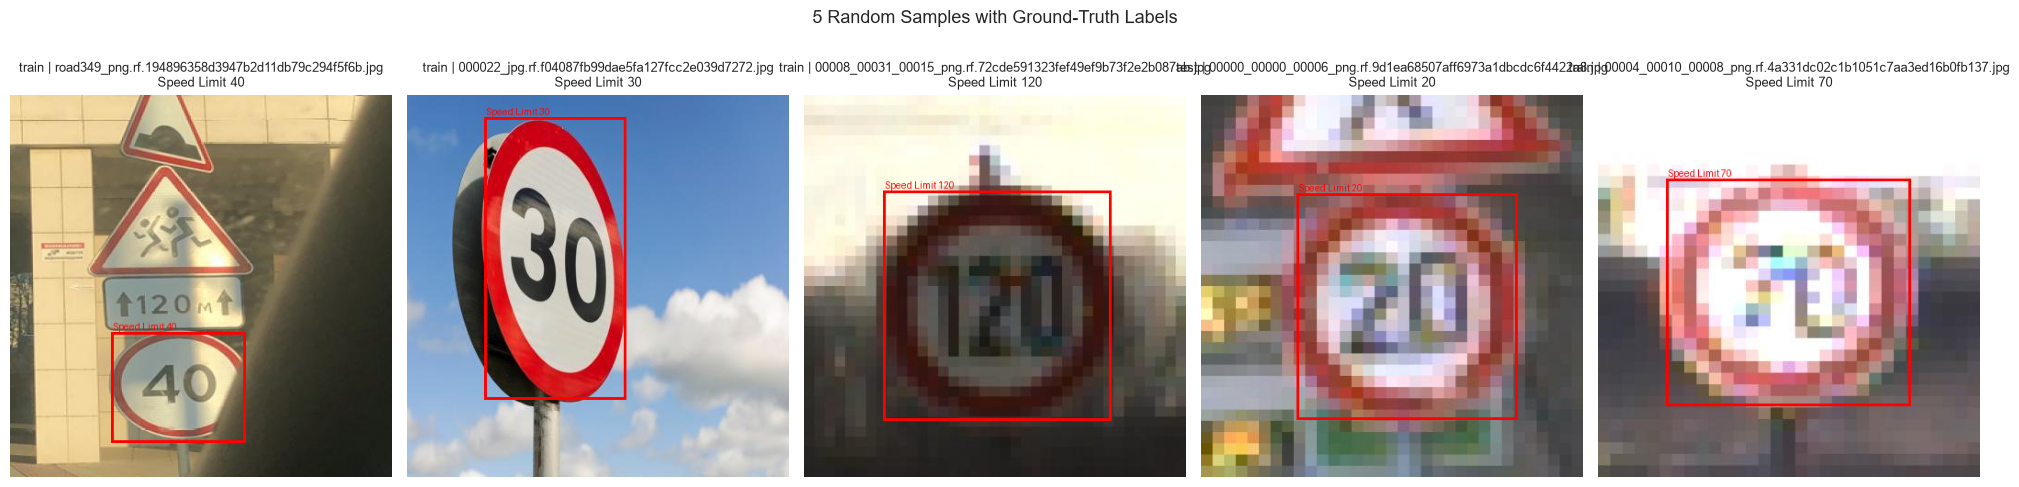

In [9]:
# ---- 5 randomly selected samples with their labels ----
def draw_boxes(image_path, inst_subset, class_names):
    img = load_image(image_path).convert("RGB").copy()
    draw = ImageDraw.Draw(img)
    for _, row in inst_subset.iterrows():
        if row["issue"] is not None:
            continue
        xmin, ymin, xmax, ymax = yolo_to_pixel_bbox(
            row["x_center"], row["y_center"], row["bbox_width"], row["bbox_height"],
            row["img_width"], row["img_height"],
        )
        draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)
        draw.text((xmin + 2, max(0, ymin - 12)), row["class_name"], fill="red")
    return img


images_with_objects = images_df[images_df["num_objects_valid"] > 0]
sample_images = images_with_objects.sample(5, random_state=RANDOM_STATE)

annotated, titles = [], []
for _, row in sample_images.iterrows():
    subset = instances_df[instances_df["image_path"] == row["image_path"]]
    annotated.append(draw_boxes(row["image_path"], subset, class_names))
    classes_here = ", ".join(sorted(subset.loc[subset["issue"].isna(), "class_name"].unique()))
    titles.append(f"{row['split']} | {row['filename']}\n{classes_here}")

plot_sample_grid(annotated, titles, ncols=5, figsize=(20, 5),
                  suptitle="5 Random Samples with Ground-Truth Labels")


## 3. Missing, Duplicate and Corrupt Entries

Each check below reports how many problematic entries were found and states explicitly what
should be done about them. **Nothing is deleted automatically anywhere in this notebook.**


In [10]:
quality_report = {}

# --- Missing files: images without a label file, or label files without an image ---
image_stems = {split: {Path(p).stem for p in images_df.loc[images_df.split == split, "image_path"]}
               for split in splits}
label_stems = {split: {Path(p).stem for p in (DATASET_PATH / split / "labels").glob("*.txt")}
               for split in splits}

images_missing_labels = sum(len(image_stems[s] - label_stems[s]) for s in splits)
labels_missing_images = sum(len(label_stems[s] - image_stems[s]) for s in splits)
quality_report["Images with no matching label file"] = images_missing_labels
quality_report["Label files with no matching image"] = labels_missing_images

# --- Missing labels: label file exists but is empty (0 annotated objects) ---
empty_label_images = int((images_df["has_label_file"] & (images_df["num_objects_total"] == 0)).sum())
quality_report["Images with an empty label file (no annotated objects)"] = empty_label_images

# --- Invalid labels: malformed lines / out-of-range class id / bad coordinates ---
invalid_lines = instances_df[instances_df["issue"].notna()]
quality_report["Invalid annotation lines (malformed / out-of-range)"] = len(invalid_lines)

# --- Degenerate bounding boxes: technically valid but too small to be a usable crop ---
MIN_BBOX_PX = 8
valid_lines = instances_df[instances_df["issue"].isna()]
degenerate = valid_lines[(valid_lines["bbox_width_px"] < MIN_BBOX_PX) |
                          (valid_lines["bbox_height_px"] < MIN_BBOX_PX)]
quality_report[f"Valid but degenerate boxes (<{MIN_BBOX_PX}px on a side)"] = len(degenerate)

print("Data quality checks so far:")
for k, v in quality_report.items():
    print(f"  {k}: {v}")

if len(invalid_lines) > 0:
    print("\nExample invalid lines:")
    display(invalid_lines.head())
if len(degenerate) > 0:
    print("\nExample degenerate boxes:")
    display(degenerate[["image_path", "class_name", "bbox_width_px", "bbox_height_px"]].head())


Data quality checks so far:
  Images with no matching label file: 0
  Label files with no matching image: 0
  Images with an empty label file (no annotated objects): 4
  Invalid annotation lines (malformed / out-of-range): 0
  Valid but degenerate boxes (<8px on a side): 996

Example degenerate boxes:


,image_path,class_name,bbox_width_px,bbox_height_px
1930,dataset\car\train\images\000783_jpg.rf.3faae75...,Red Light,6.0,22.0
1931,dataset\car\train\images\000783_jpg.rf.3faae75...,Red Light,6.5,18.0
1932,dataset\car\train\images\000783_jpg.rf.3faae75...,Speed Limit 40,7.5,15.0
1941,dataset\car\train\images\000788_jpg.rf.2dd10c3...,Green Light,7.5,34.5
1950,dataset\car\train\images\000795_jpg.rf.74bd9dd...,Green Light,6.5,19.5


In [11]:
# --- Corrupt / unreadable images ---
all_image_paths = images_df["image_path"].tolist()
corrupt_images = check_corrupt_images(all_image_paths)
quality_report["Corrupt / unreadable images"] = len(corrupt_images)
print(f"Corrupt/unreadable images found: {len(corrupt_images)}")
for p, err in corrupt_images[:5]:
    print(f"  {p}: {err}")

# --- Unsupported image formats ---
SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
unsupported = images_df[~images_df["extension"].isin(SUPPORTED_EXTS)]
quality_report["Unsupported file extensions"] = len(unsupported)
print(f"\nFile extensions found: {images_df['extension'].value_counts().to_dict()}")

# --- Unexpected channels (mode) ---
mode_counts = images_df["mode"].value_counts()
non_rgb = images_df[(images_df["mode"].notna()) & (images_df["mode"] != "RGB")]
quality_report["Images with a non-RGB color mode"] = len(non_rgb)
print(f"\nColor mode distribution: {mode_counts.to_dict()}")


Corrupt/unreadable images found: 0

File extensions found: {'.jpg': 4969}

Color mode distribution: {'RGB': 4969}


In [12]:
# --- Duplicate images (exact byte-identical files) & duplicate filenames ---
hash_map = {}
for p in all_image_paths:
    h = compute_file_hash(p)
    hash_map.setdefault(h, []).append(p)

dup_groups = {h: ps for h, ps in hash_map.items() if len(ps) > 1}
n_duplicate_files = sum(len(ps) - 1 for ps in dup_groups.values())  # extra copies beyond the first
quality_report["Duplicate images (exact byte-identical copies)"] = n_duplicate_files

# Do any duplicate groups cross a train/valid/test boundary? (data leakage risk)
def split_of(path):
    return Path(path).parts[-3]  # .../<split>/images/<file>

leaking_groups = [ps for ps in dup_groups.values() if len({split_of(p) for p in ps}) > 1]
quality_report["Duplicate groups that cross train/valid/test (possible leakage)"] = len(leaking_groups)

# Duplicate filenames (same filename appearing more than once anywhere in the dataset)
filename_counts = Counter(images_df["filename"])
dup_filenames = {name: c for name, c in filename_counts.items() if c > 1}
quality_report["Duplicate filenames (same name reused)"] = len(dup_filenames)

print(f"Duplicate-image groups: {len(dup_groups)} (representing {n_duplicate_files} redundant files)")
print(f"Of those, groups spanning more than one split: {len(leaking_groups)}")
print(f"Duplicate filenames reused across the dataset: {len(dup_filenames)}")


Duplicate-image groups: 230 (representing 230 redundant files)
Of those, groups spanning more than one split: 101
Duplicate filenames reused across the dataset: 0


In [13]:
# ---- Summary table + recommended action for every problem class checked ----
recommendations = {
    "Images with no matching label file": "Retain as an unlabeled/background image if any exist; "
        "exclude from classification-style analyses since they contribute no class label.",
    "Label files with no matching image": "Remove the orphan label file — it cannot be used without its image.",
    "Images with an empty label file (no annotated objects)": "Retain as a 'no sign present' background "
        "example if the downstream task needs negatives; otherwise exclude from per-class crop analyses "
        "since they contain no class instance.",
    "Invalid annotation lines (malformed / out-of-range)": "Fix if the fix is unambiguous (e.g. reorder "
        "fields); otherwise drop only the offending line, not the whole image — the rest of that image's "
        "valid boxes remain usable.",
    f"Valid but degenerate boxes (<{MIN_BBOX_PX}px on a side)": "Exclude from crop-based analyses "
        "(Part B) and from CNN training data — a box this small carries almost no visual signal and "
        "would just become noise after resizing.",
    "Corrupt / unreadable images": "Remove from the dataset (and re-export/re-download if possible); "
        "an unreadable file cannot be used for training or evaluation.",
    "Unsupported file extensions": "Convert to a supported format (e.g. PNG/JPEG) before training, or "
        "exclude if conversion is not possible.",
    "Images with a non-RGB color mode": "Convert to RGB during preprocessing (most CNN backbones expect "
        "3 channels) rather than discarding the image.",
    "Duplicate images (exact byte-identical copies)": "Keep one copy per duplicate group; remove the rest "
        "to avoid the model seeing (and evaluation double-counting) the same image twice.",
    "Duplicate groups that cross train/valid/test (possible leakage)": "High priority: remove duplicates "
        "from validation/test (keep only in train) so validation/test performance is not inflated by "
        "leakage from images the model has already seen.",
    "Duplicate filenames (same name reused)": "Not necessarily a problem if files live in different split "
        "folders and are legitimately different images (Roboflow filenames include a content hash suffix); "
        "verify content via the duplicate-image hash check above before taking any action.",
}

report_df = pd.DataFrame([
    {"Check": k, "Count": v, "Recommended action": recommendations.get(k, "Review manually.")}
    for k, v in quality_report.items()
])
report_df


,Check,Count,Recommended action
0,Images with no matching label file,0,Retain as an unlabeled/background image if any...
1,Label files with no matching image,0,Remove the orphan label file — it cannot be us...
2,Images with an empty label file (no annotated ...,4,Retain as a 'no sign present' background examp...
3,Invalid annotation lines (malformed / out-of-r...,0,Fix if the fix is unambiguous (e.g. reorder fi...
4,Valid but degenerate boxes (<8px on a side),996,Exclude from crop-based analyses (Part B) and ...
5,Corrupt / unreadable images,0,Remove from the dataset (and re-export/re-down...
6,Unsupported file extensions,0,Convert to a supported format (e.g. PNG/JPEG) ...
7,Images with a non-RGB color mode,0,Convert to RGB during preprocessing (most CNN ...
8,Duplicate images (exact byte-identical copies),230,Keep one copy per duplicate group; remove the ...
9,Duplicate groups that cross train/valid/test (...,101,High priority: remove duplicates from validati...


## 4. Class / Target Distribution

Because this dataset is annotated per bounding box (an image can contain more than one sign),
class distribution is computed at the **instance level**: every valid annotated bounding box
counts as one labeled example of its class. This is the distribution a classifier trained on the
cropped signs would actually see.


In [14]:
clean_instances_df = instances_df[
    instances_df["issue"].isna()
    & (instances_df["bbox_width_px"] >= MIN_BBOX_PX)
    & (instances_df["bbox_height_px"] >= MIN_BBOX_PX)
].copy()

print(f"Valid, non-degenerate annotated instances usable for classification EDA: "
      f"{len(clean_instances_df)} (out of {len(instances_df)} total annotation lines)")

class_counts = clean_instances_df["class_name"].value_counts()
class_table = class_counts.rename("count").to_frame()
class_table["percentage"] = (class_table["count"] / class_table["count"].sum() * 100).round(2)
class_table


Valid, non-degenerate annotated instances usable for classification EDA: 5016 (out of 6012 total annotation lines)


,count,percentage
class_name,,
Green Light,468,9.33
Speed Limit 30,438,8.73
Speed Limit 80,416,8.29
Stop,416,8.29
Red Light,410,8.17
Speed Limit 70,406,8.09
Speed Limit 60,393,7.83
Speed Limit 20,362,7.22
Speed Limit 50,362,7.22


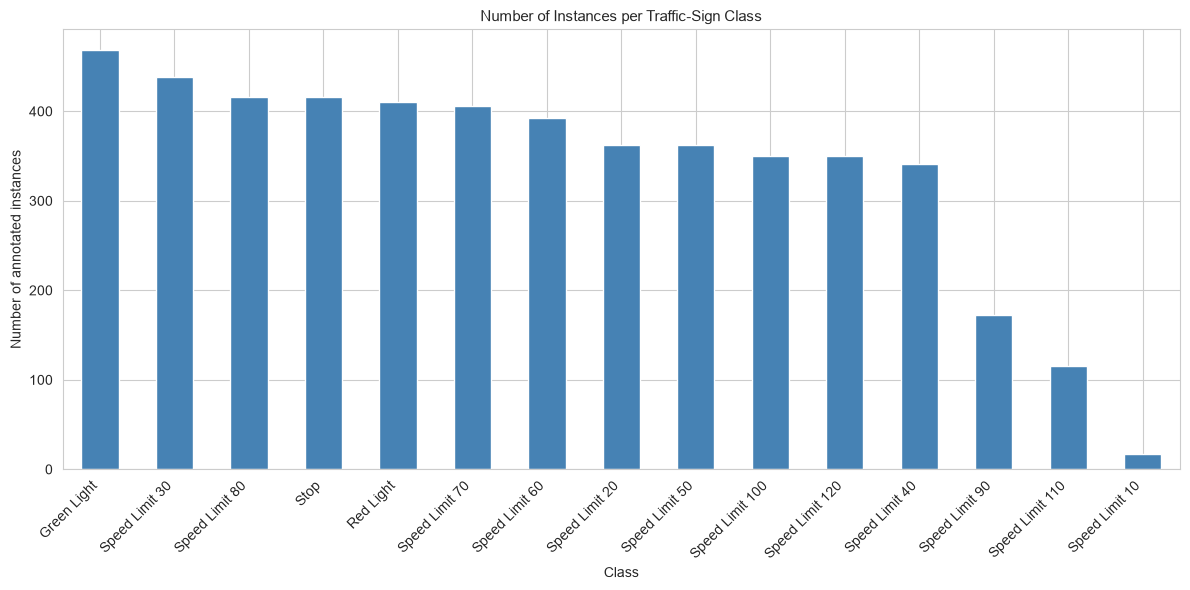

In [15]:
plot_class_distribution(class_counts, title="Number of Instances per Traffic-Sign Class",
                         xlabel="Class", ylabel="Number of annotated instances")


In [16]:
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
imbalance_ratio = class_counts.max() / class_counts.min()

display(Markdown(f"""
**Interpretation:**

- The most frequent class is **{majority_class}** with **{class_counts.max()}** instances
  ({class_table.loc[majority_class, 'percentage']}% of all instances).
- The least frequent class is **{minority_class}** with only **{class_counts.min()}** instances
  ({class_table.loc[minority_class, 'percentage']}% of all instances).
- The imbalance ratio between the largest and smallest class is **{imbalance_ratio:.1f}:1**, so the
  dataset is **not balanced**.
- A CNN trained naively on this distribution is likely to be biased toward the majority classes and
  perform poorly on **{minority_class}**, since it sees very few examples of that class relative to
  the others.
- To counter this, class weighting (e.g. inverse-frequency loss weights), oversampling of minority
  classes, and/or targeted data augmentation for the rarest classes should be considered during
  training — not just generic augmentation applied uniformly to every class.
"""))



**Interpretation:**

- The most frequent class is **Green Light** with **468** instances
  (9.33% of all instances).
- The least frequent class is **Speed Limit 10** with only **17** instances
  (0.34% of all instances).
- The imbalance ratio between the largest and smallest class is **27.5:1**, so the
  dataset is **not balanced**.
- A CNN trained naively on this distribution is likely to be biased toward the majority classes and
  perform poorly on **Speed Limit 10**, since it sees very few examples of that class relative to
  the others.
- To counter this, class weighting (e.g. inverse-frequency loss weights), oversampling of minority
  classes, and/or targeted data augmentation for the rarest classes should be considered during
  training — not just generic augmentation applied uniformly to every class.


## 5. Train / Validation / Test Split

The dataset already ships with a train/valid/test split created by Roboflow. We first check how
that existing split is proportioned and whether it is roughly stratified by class, then
demonstrate the recommended **stratified** split methodology on the instance-level (cropped-sign)
data. No model is trained here — this only prepares/validates a split strategy.


In [17]:
existing_split_sizes = images_df["split"].value_counts()
existing_split_pct = (existing_split_sizes / existing_split_sizes.sum() * 100).round(1)
print("Existing Roboflow split (by image count):")
for s in splits:
    print(f"  {s:5s}: {existing_split_sizes[s]:5d} images ({existing_split_pct[s]}%)")


Existing Roboflow split (by image count):
  train:  3530 images (71.0%)
  valid:   801 images (16.1%)
  test :   638 images (12.8%)


In [18]:
# Is the existing split roughly stratified per class (instance-level)?
split_class_pct = (
    clean_instances_df.groupby("split")["class_name"]
    .value_counts(normalize=True)
    .unstack(fill_value=0.0) * 100
).round(2)
split_class_pct = split_class_pct[class_counts.index]  # order columns by overall frequency
split_class_pct


class_name,Green Light,Speed Limit 30,Speed Limit 80,Stop,Red Light,Speed Limit 70,Speed Limit 60,Speed Limit 20,Speed Limit 50,Speed Limit 100,Speed Limit 120,Speed Limit 40,Speed Limit 90,Speed Limit 110,Speed Limit 10
split,,,,,,,,,,,,,,,
test,11.11,8.33,9.10,7.72,7.25,7.10,6.79,6.79,6.79,6.64,6.79,8.18,4.32,2.78,0.31
train,8.92,8.78,8.58,8.04,8.44,8.04,7.84,7.48,7.11,7.28,6.94,6.57,3.27,2.29,0.42
valid,9.71,8.86,6.43,9.83,7.77,9.10,8.62,6.43,8.01,5.95,7.28,6.67,3.40,1.94,0.00


In [19]:
rare_classes = class_counts[class_counts < 50]
display(Markdown(f"""
**Observation:** Comparing per-class percentages across `train` / `valid` / `test` above shows the
existing split is reasonably close to stratified for the higher-count classes, but classes with
very few total instances (e.g. {', '.join(rare_classes.index) if len(rare_classes) else 'none below 50 instances'})
are represented by only a handful of examples in `valid`/`test`, so their per-split percentages can
swing widely just from a few images landing on one side or the other.
"""))



**Observation:** Comparing per-class percentages across `train` / `valid` / `test` above shows the
existing split is reasonably close to stratified for the higher-count classes, but classes with
very few total instances (e.g. Speed Limit 10)
are represented by only a handful of examples in `valid`/`test`, so their per-split percentages can
swing widely just from a few images landing on one side or the other.


In [20]:
# ---- Recommended stratified split, demonstrated on the instance-level (crop) dataset ----
TRAIN_PCT, VAL_PCT, TEST_PCT = 0.70, 0.15, 0.15
assert abs(TRAIN_PCT + VAL_PCT + TEST_PCT - 1.0) < 1e-9

X = clean_instances_df.index.values
y = clean_instances_df["class_name"].values

train_idx, temp_idx, y_train, y_temp = train_test_split(
    X, y, train_size=TRAIN_PCT, stratify=y, random_state=RANDOM_STATE
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, train_size=VAL_PCT / (VAL_PCT + TEST_PCT),
    stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Recommended split sizes -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")

check_df = pd.DataFrame({
    "train_%": pd.Series(y_train).value_counts(normalize=True) * 100,
    "val_%": pd.Series(y_val).value_counts(normalize=True) * 100,
    "test_%": pd.Series(y_test).value_counts(normalize=True) * 100,
}).round(2).loc[class_counts.index]
check_df


Recommended split sizes -> train: 3511, val: 752, test: 753


,train_%,val_%,test_%
class_name,,,
Green Light,9.34,9.31,9.30
Speed Limit 30,8.74,8.64,8.76
Speed Limit 80,8.29,8.24,8.37
Stop,8.29,8.24,8.37
Red Light,8.17,8.11,8.23
Speed Limit 70,8.09,8.11,8.10
Speed Limit 60,7.83,7.85,7.84
Speed Limit 20,7.21,7.31,7.17
Speed Limit 50,7.21,7.18,7.30


**Why this split / why stratified:**

* **70% train / 15% validation / 15% test** gives the CNN enough examples to learn from while still
  leaving statistically meaningful validation and test sets, given the dataset only has ~6,000
  usable instances in total (not millions), so a larger test share would starve training and a
  smaller one would make test metrics noisy.
* **Stratification** (via `train_test_split(..., stratify=y)`) is used instead of a plain random
  split because the dataset is already class-imbalanced (Section 4). A non-stratified split risks a
  rare class such as the minority class identified above ending up with zero examples in validation
  or test purely by chance, which would make that class impossible to evaluate.
* The table above confirms the stratified split keeps each class's percentage share almost identical
  across train/val/test — this is exactly what prevents the split itself from *adding* extra
  imbalance on top of the dataset's existing class imbalance.
* For the rarest classes (only a few dozen instances total), even a stratified 70/15/15 split leaves
  very few validation/test examples per class — this is flagged as Finding 3 below.


## 6. Three Important Findings


In [21]:
finding3_min_count = class_counts.min()
n_images_in_leaking_groups = sum(len(ps) for ps in leaking_groups)

display(Markdown(f"""
### Finding 1 — Duplicate images leak across the train/valid/test split boundary

- **Observed:** {len(dup_groups)} groups of byte-identical duplicate images were found in the
  dataset ({n_duplicate_files} redundant files in total). Of those groups, **{len(leaking_groups)}
  span more than one split** (train/valid/test), involving {n_images_in_leaking_groups} images.
- **Evidence:** Section 3's duplicate-image check hashes every image file and groups exact matches;
  the split membership of each match was then checked directly against `images_df['split']`.
- **Why it matters:** If the same image appears in both `train` and `test` (or `valid`), the model
  can effectively memorize that exact image during training and then be evaluated on it again,
  inflating reported validation/test accuracy in a way that will not hold up on genuinely unseen
  images — this undermines the reliability of any accuracy number reported from this split.
- **Model design impact:** Before training, deduplicate the dataset so each duplicate group keeps
  only one copy, and always keep that copy in `train` (drop the copies from `valid`/`test`) so
  evaluation only ever sees images the model has not trained on.

### Finding 2 — Severe class imbalance dominated by one rare class

- **Observed:** Instance-level class counts (Section 4) range from **{class_counts.max()}**
  ({majority_class}) down to just **{class_counts.min()}** ({minority_class}) — an imbalance ratio
  of **{imbalance_ratio:.1f}:1**.
- **Evidence:** The class-distribution bar chart and count table in Section 4 show
  {minority_class} sitting far below every other class, while {majority_class} and the other
  'light' class dominate the dataset.
- **Why it matters:** With so few examples of {minority_class}, a CNN trained with a standard
  cross-entropy loss and no correction will be biased toward predicting the majority classes, and
  {minority_class} accuracy/recall will likely be poor purely from lack of exposure, not because the
  class is visually harder. It also means, as Section 5 shows, that even a stratified split leaves
  only a handful of {minority_class} examples in validation/test, making that class's metrics noisy.
- **Model design impact:** Use class-weighted loss (inverse-frequency weighting), oversample or
  augment {minority_class} specifically, and evaluate with per-class recall/F1 and a confusion
  matrix (not just overall accuracy) so this class's performance is visible rather than hidden by
  the majority classes.

### Finding 3 — This is a detection-style dataset with multi-object images and highly variable sign sizes, not a ready-made classification dataset

- **Observed:** Some images contain more than one annotated sign/light (multiple bounding boxes per
  image), and the sizes of those bounding boxes vary hugely within a fixed 416x416 frame — including
  {quality_report[f'Valid but degenerate boxes (<{MIN_BBOX_PX}px on a side)']} boxes so small
  (under {MIN_BBOX_PX}px on a side) that they carry almost no visual information.
- **Evidence:** Section 2/3 show images with `num_objects_valid > 1`, and the degenerate-box check in
  Section 3 found boxes as small as a few pixels on a side alongside boxes spanning most of the
  416x416 frame.
- **Why it matters:** A raw full image cannot be fed to a single-label classifier as-is — it may
  contain zero, one, or several different sign classes. The dataset must first be converted to
  single-object crops (as this notebook does for its Part B analyses), and any crop that is too
  small to carry real visual information should be filtered out before training.
- **Model design impact:** The classification pipeline needs a crop step (using the bounding boxes)
  before any CNN input, a minimum-size filter to drop degenerate boxes, and a fixed target
  resolution chosen from the crop size distribution (see Section 7) rather than assuming the
  original 416x416 frame size.
"""))



### Finding 1 — Duplicate images leak across the train/valid/test split boundary

- **Observed:** 230 groups of byte-identical duplicate images were found in the
  dataset (230 redundant files in total). Of those groups, **101
  span more than one split** (train/valid/test), involving 202 images.
- **Evidence:** Section 3's duplicate-image check hashes every image file and groups exact matches;
  the split membership of each match was then checked directly against `images_df['split']`.
- **Why it matters:** If the same image appears in both `train` and `test` (or `valid`), the model
  can effectively memorize that exact image during training and then be evaluated on it again,
  inflating reported validation/test accuracy in a way that will not hold up on genuinely unseen
  images — this undermines the reliability of any accuracy number reported from this split.
- **Model design impact:** Before training, deduplicate the dataset so each duplicate group keeps
  only one copy, and always keep that copy in `train` (drop the copies from `valid`/`test`) so
  evaluation only ever sees images the model has not trained on.

### Finding 2 — Severe class imbalance dominated by one rare class

- **Observed:** Instance-level class counts (Section 4) range from **468**
  (Green Light) down to just **17** (Speed Limit 10) — an imbalance ratio
  of **27.5:1**.
- **Evidence:** The class-distribution bar chart and count table in Section 4 show
  Speed Limit 10 sitting far below every other class, while Green Light and the other
  'light' class dominate the dataset.
- **Why it matters:** With so few examples of Speed Limit 10, a CNN trained with a standard
  cross-entropy loss and no correction will be biased toward predicting the majority classes, and
  Speed Limit 10 accuracy/recall will likely be poor purely from lack of exposure, not because the
  class is visually harder. It also means, as Section 5 shows, that even a stratified split leaves
  only a handful of Speed Limit 10 examples in validation/test, making that class's metrics noisy.
- **Model design impact:** Use class-weighted loss (inverse-frequency weighting), oversample or
  augment Speed Limit 10 specifically, and evaluate with per-class recall/F1 and a confusion
  matrix (not just overall accuracy) so this class's performance is visible rather than hidden by
  the majority classes.

### Finding 3 — This is a detection-style dataset with multi-object images and highly variable sign sizes, not a ready-made classification dataset

- **Observed:** Some images contain more than one annotated sign/light (multiple bounding boxes per
  image), and the sizes of those bounding boxes vary hugely within a fixed 416x416 frame — including
  996 boxes so small
  (under 8px on a side) that they carry almost no visual information.
- **Evidence:** Section 2/3 show images with `num_objects_valid > 1`, and the degenerate-box check in
  Section 3 found boxes as small as a few pixels on a side alongside boxes spanning most of the
  416x416 frame.
- **Why it matters:** A raw full image cannot be fed to a single-label classifier as-is — it may
  contain zero, one, or several different sign classes. The dataset must first be converted to
  single-object crops (as this notebook does for its Part B analyses), and any crop that is too
  small to carry real visual information should be filtered out before training.
- **Model design impact:** The classification pipeline needs a crop step (using the bounding boxes)
  before any CNN input, a minimum-size filter to drop degenerate boxes, and a fixed target
  resolution chosen from the crop size distribution (see Section 7) rather than assuming the
  original 416x416 frame size.


# Part B — Image / Vision

## 7. Image Size and Channel Distribution

First we check the **raw images** (as exported by Roboflow), then the **cropped sign instances**
that a classifier would actually be trained on — since raw-image size and crop size can tell very
different stories for a detection-derived dataset like this one.


In [22]:
raw_dim_df = analyze_image_dimensions(zip(images_df["width"].dropna(), images_df["height"].dropna()))
print("Raw image dimensions (all", len(raw_dim_df), "images):")
print(raw_dim_df.describe())
print("\nUnique (width, height) combinations found:",
      raw_dim_df[["width", "height"]].drop_duplicates().shape[0])


Raw image dimensions (all 4969 images):
        width  height  aspect_ratio
count  4969.0  4969.0        4969.0
mean    416.0   416.0           1.0
std       0.0     0.0           0.0
min     416.0   416.0           1.0
25%     416.0   416.0           1.0
50%     416.0   416.0           1.0
75%     416.0   416.0           1.0
max     416.0   416.0           1.0

Unique (width, height) combinations found: 1


In [23]:
crop_dim_df = analyze_image_dimensions(
    zip(clean_instances_df["bbox_width_px"], clean_instances_df["bbox_height_px"])
)
print("Cropped-instance dimensions (all", len(crop_dim_df), "valid, non-degenerate crops):")
print(crop_dim_df.describe())


Cropped-instance dimensions (all 5016 valid, non-degenerate crops):
             width       height  aspect_ratio
count  5016.000000  5016.000000   5016.000000
mean    161.895734   171.431818      1.019759
std     112.463439   117.275609      0.462216
min       8.000000     8.000000      0.128603
25%      51.500000    46.500000      0.720406
50%     151.500000   181.000000      0.983099
75%     266.625000   278.000000      1.222222
max     416.000000   416.000000      4.593750


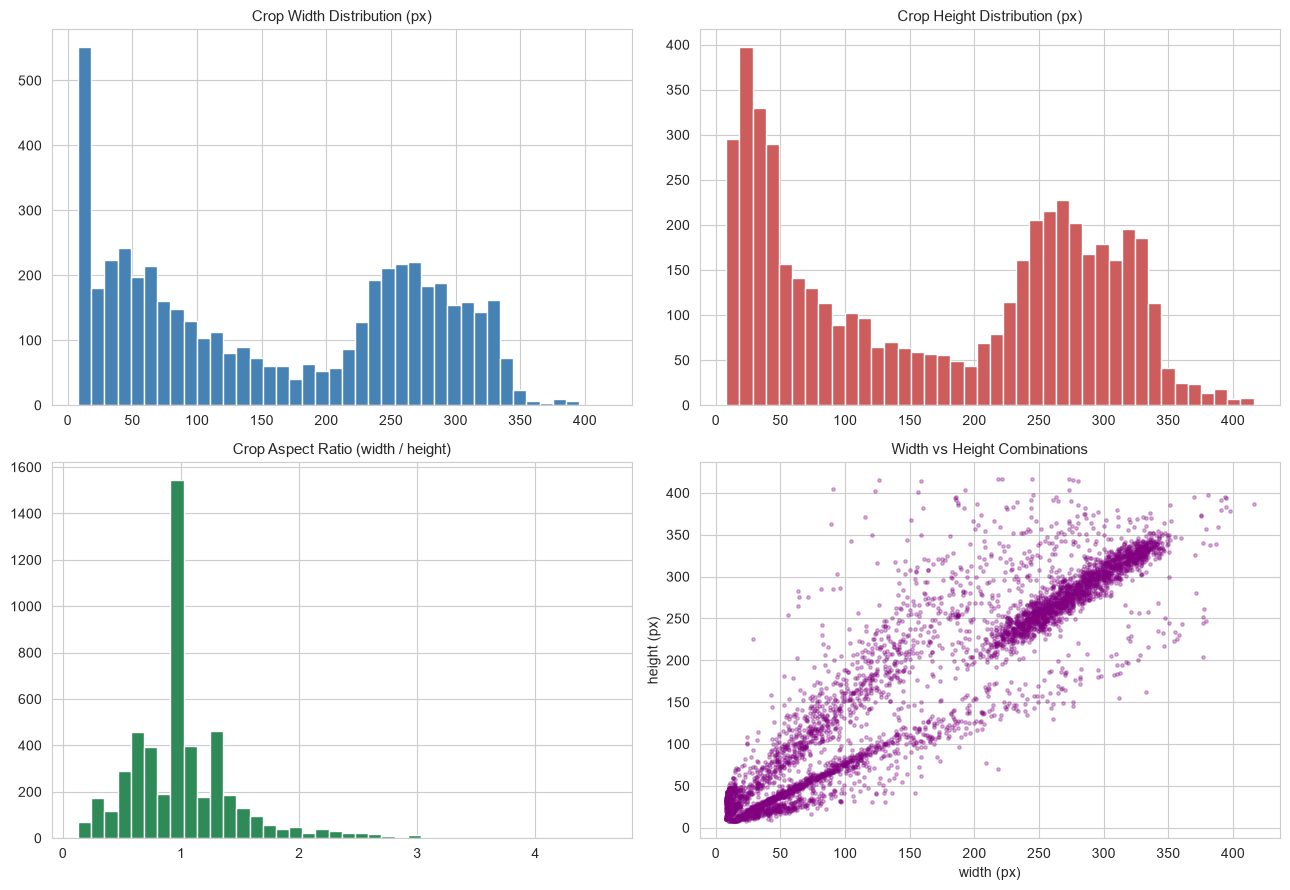

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].hist(crop_dim_df["width"], bins=40, color="steelblue")
axes[0, 0].set_title("Crop Width Distribution (px)")
axes[0, 1].hist(crop_dim_df["height"], bins=40, color="indianred")
axes[0, 1].set_title("Crop Height Distribution (px)")
axes[1, 0].hist(crop_dim_df["aspect_ratio"], bins=40, color="seagreen")
axes[1, 0].set_title("Crop Aspect Ratio (width / height)")
axes[1, 1].scatter(crop_dim_df["width"], crop_dim_df["height"], s=6, alpha=0.3, color="purple")
axes[1, 1].set_xlabel("width (px)")
axes[1, 1].set_ylabel("height (px)")
axes[1, 1].set_title("Width vs Height Combinations")
plt.tight_layout()
plt.show()


In [25]:
mode_dist = images_df["mode"].value_counts()
print("Raw image color-mode distribution (RGB / grayscale / RGBA):")
print(mode_dist)


Raw image color-mode distribution (RGB / grayscale / RGBA):
mode
RGB    4969
Name: count, dtype: int64


In [26]:
# ---- Data-driven target resolution recommendation ----
median_side = crop_dim_df[["width", "height"]].max(axis=1).median()

def recommend_resolution(median_dim):
    candidates = [32, 48, 64, 96, 128]
    thresholds = [48, 80, 160, 300]
    for cand, thresh in zip(candidates, thresholds):
        if median_dim < thresh:
            return cand
    return candidates[-1]

TARGET_SIZE = recommend_resolution(median_side)

display(Markdown(f"""
**Recommended target resolution: {TARGET_SIZE}x{TARGET_SIZE}**

- All raw images share a single fixed size ({int(raw_dim_df['width'].iloc[0])}x{int(raw_dim_df['height'].iloc[0])}),
  since Roboflow already resized them on export — so raw-image size gives no useful signal for
  choosing a CNN input resolution.
- The cropped-sign instances (what the classifier is actually trained on) vary widely: width ranges
  from {int(crop_dim_df['width'].min())}px to {int(crop_dim_df['width'].max())}px, with a median of
  {crop_dim_df['width'].median():.0f}px, and height ranges from {int(crop_dim_df['height'].min())}px
  to {int(crop_dim_df['height'].max())}px with a median of {crop_dim_df['height'].median():.0f}px.
- The median of the larger side of each crop is **{median_side:.0f}px**, which falls in the range
  that maps to **{TARGET_SIZE}x{TARGET_SIZE}** using the size buckets above — large enough to keep
  the fine digit/shape detail that distinguishes similar sign classes (see Finding 3 below), while
  still small enough to be computationally efficient given most crops are well under 200px.
"""))



**Recommended target resolution: 96x96**

- All raw images share a single fixed size (416x416),
  since Roboflow already resized them on export — so raw-image size gives no useful signal for
  choosing a CNN input resolution.
- The cropped-sign instances (what the classifier is actually trained on) vary widely: width ranges
  from 8px to 416px, with a median of
  152px, and height ranges from 8px
  to 416px with a median of 181px.
- The median of the larger side of each crop is **203px**, which falls in the range
  that maps to **96x96** using the size buckets above — large enough to keep
  the fine digit/shape detail that distinguishes similar sign classes (see Finding 3 below), while
  still small enough to be computationally efficient given most crops are well under 200px.


## 8. Grid of Samples per Class

Representative cropped examples for every class, split across multiple figures (5 classes per
figure) so each figure stays readable.


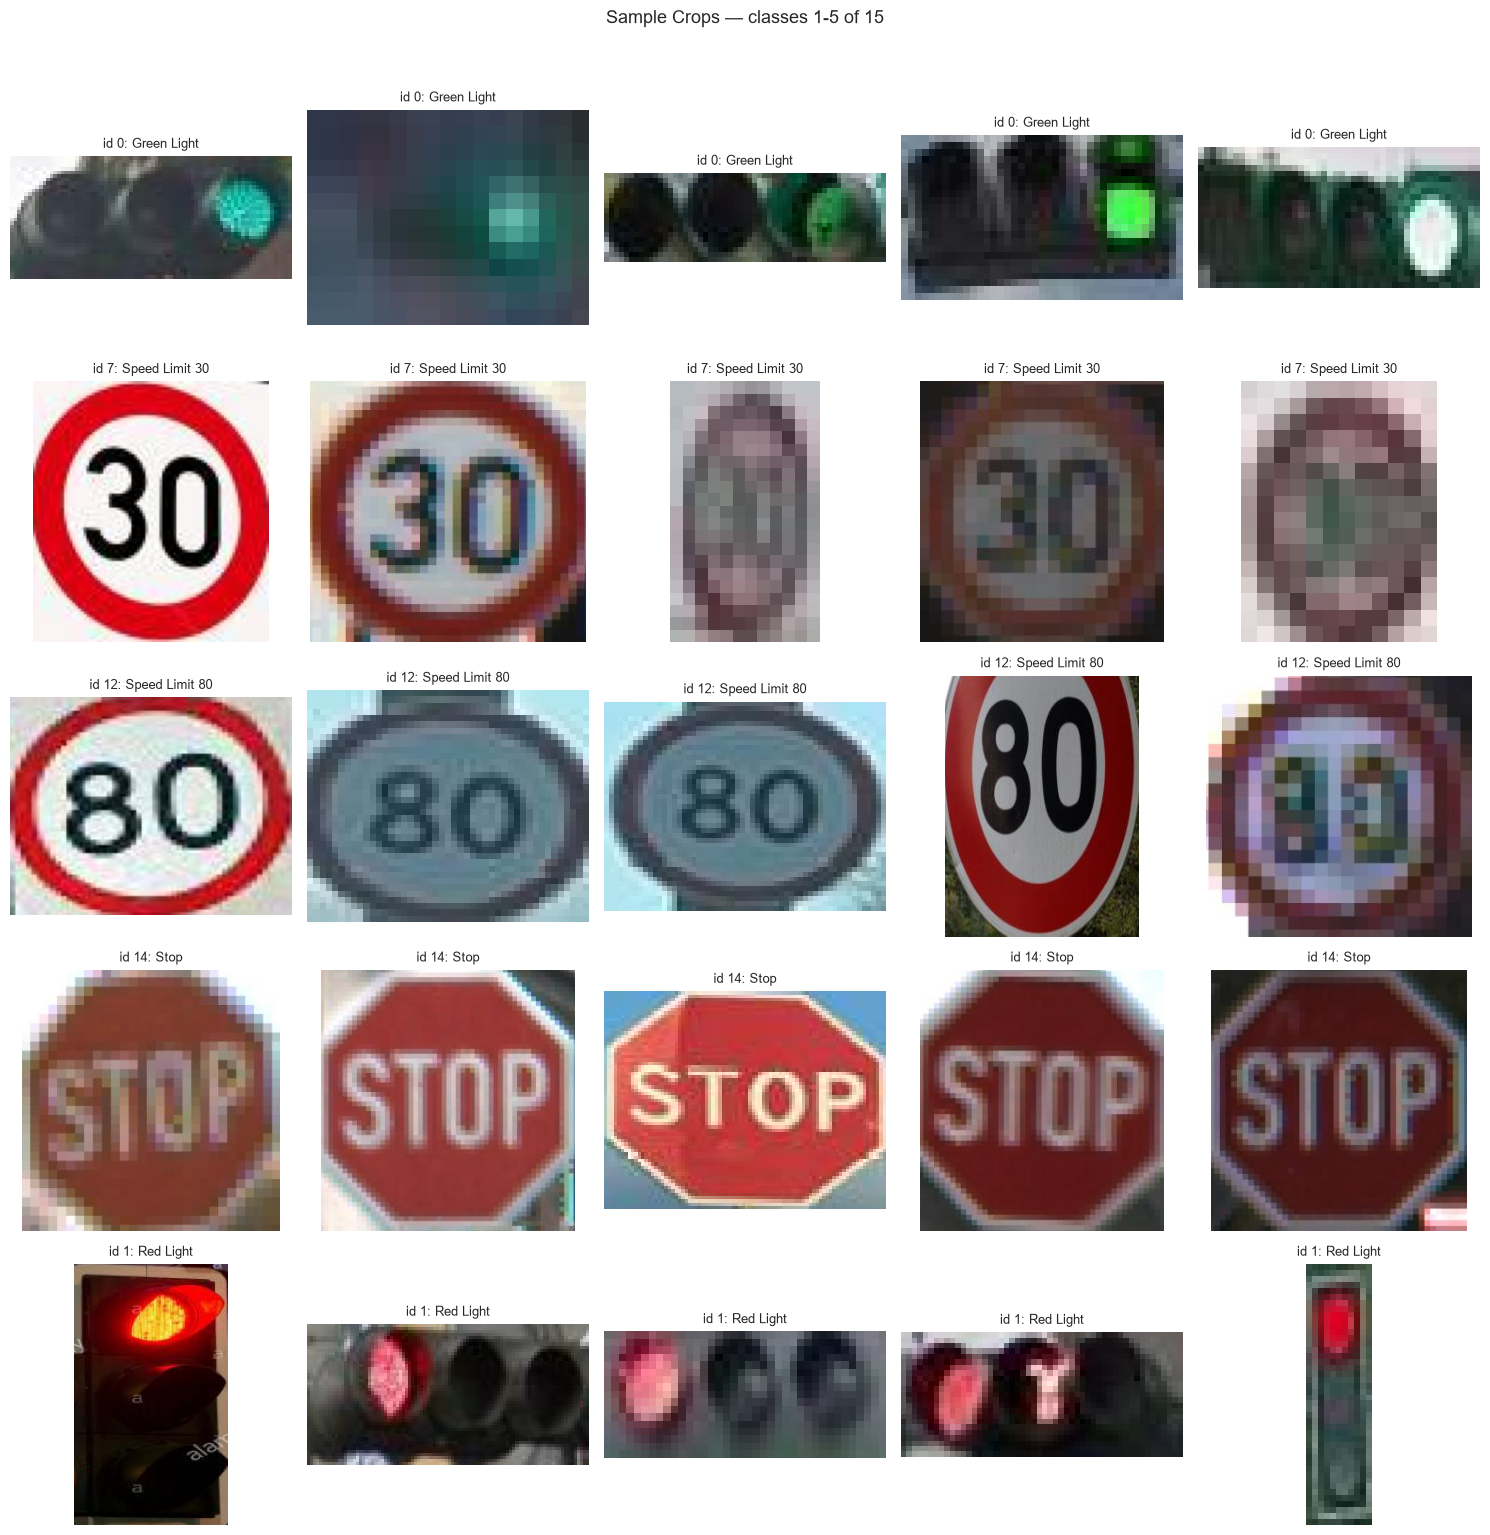

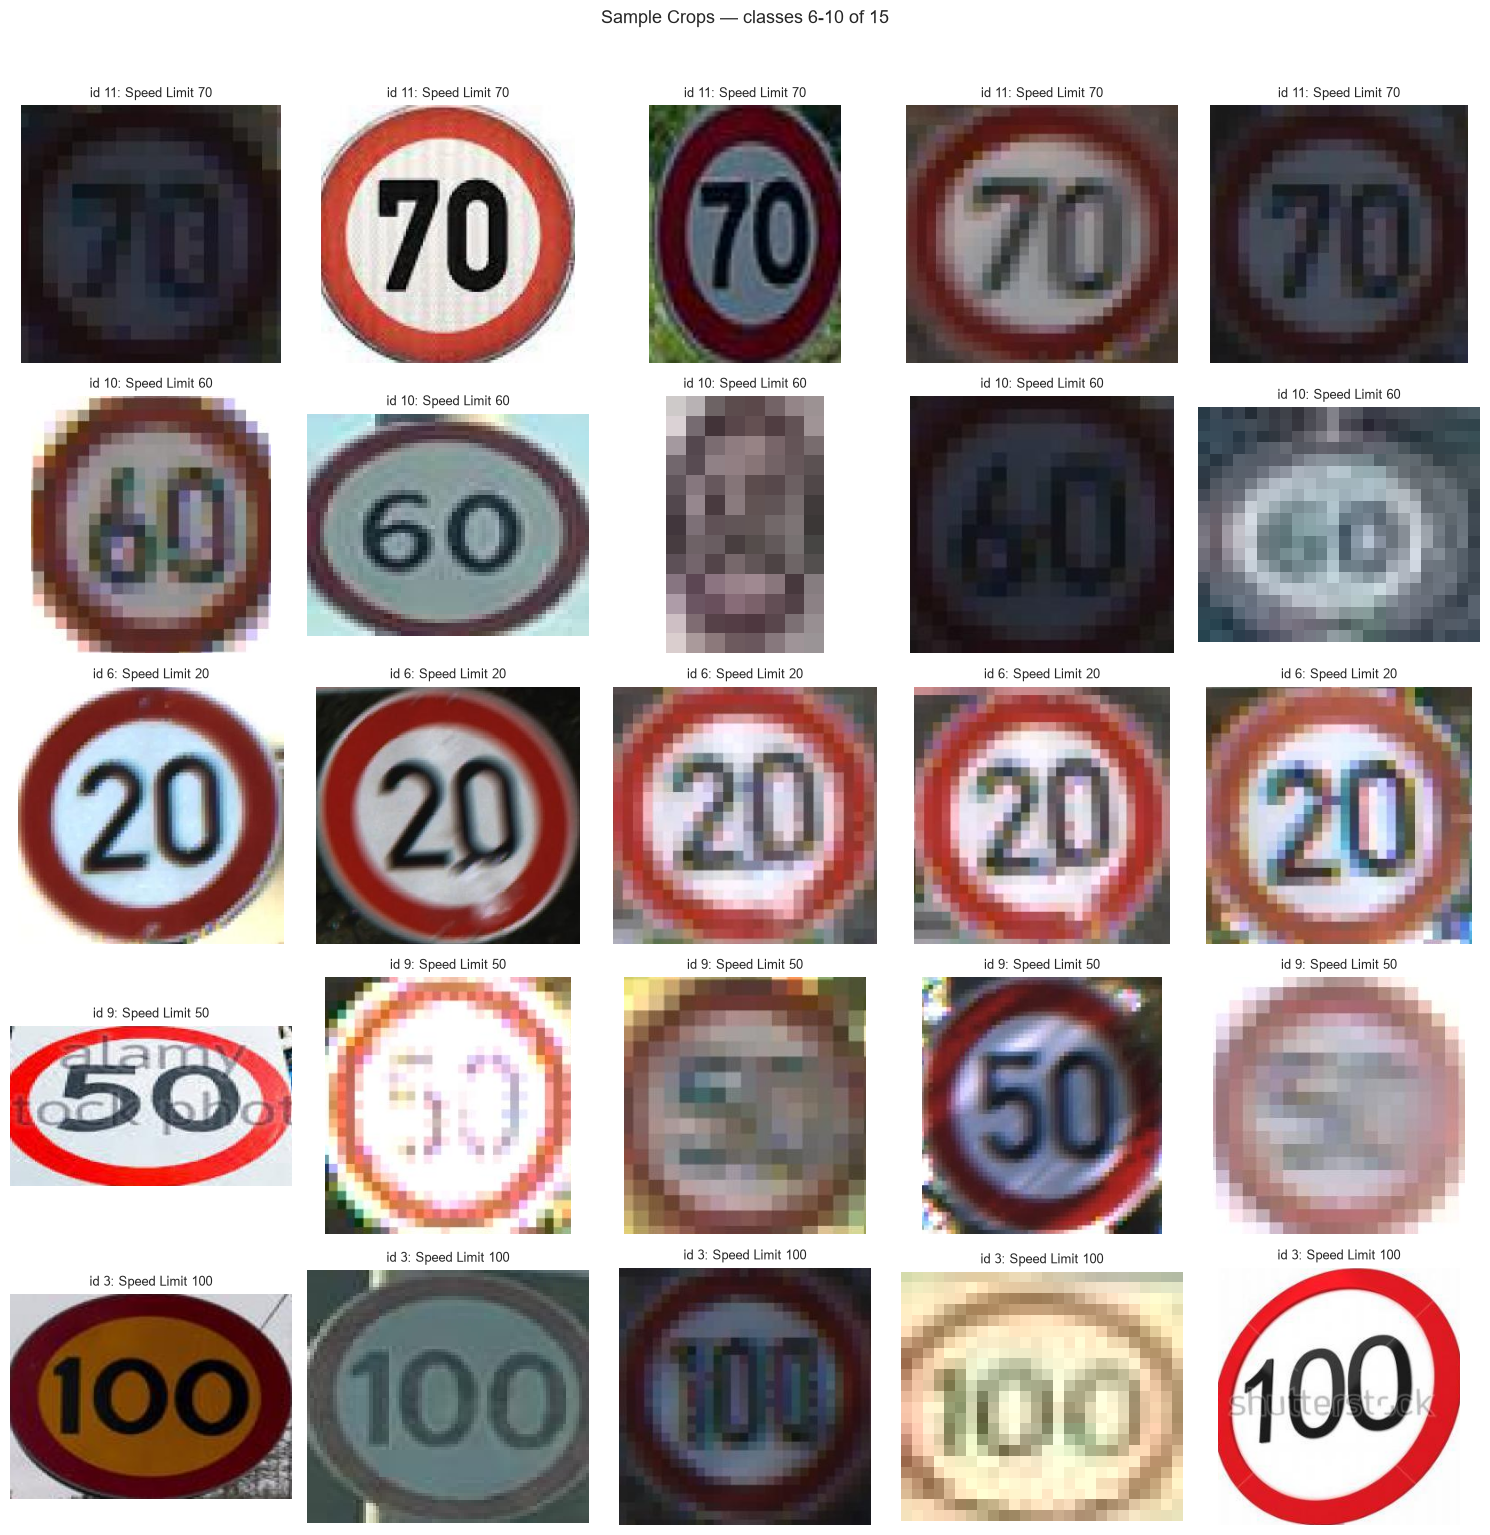

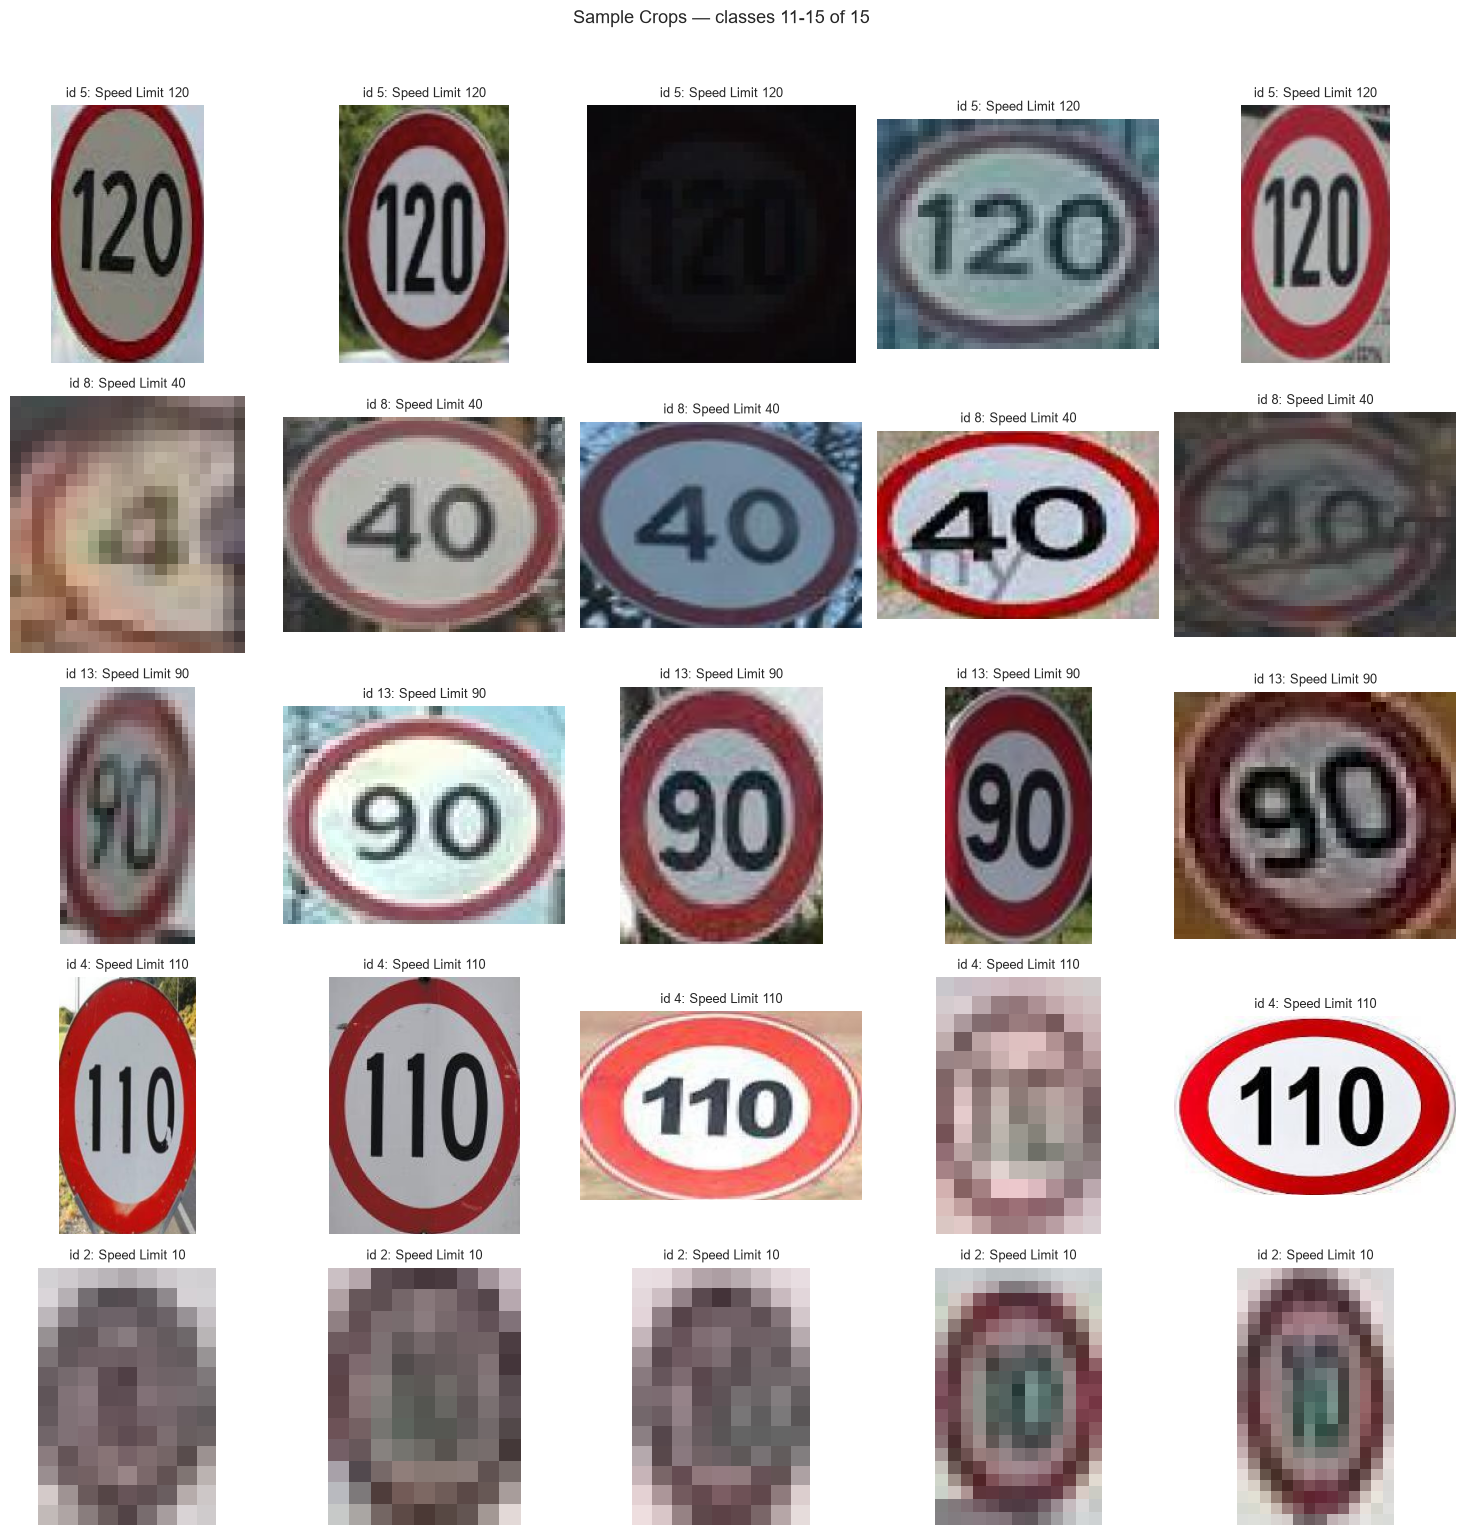

In [27]:
SAMPLES_PER_CLASS = 5
class_order = class_counts.index.tolist()

def build_class_sample_grid(class_subset):
    imgs, titles = [], []
    for cname in class_subset:
        rows = clean_instances_df[clean_instances_df["class_name"] == cname]
        n = min(SAMPLES_PER_CLASS, len(rows))
        rows = rows.sample(n, random_state=RANDOM_STATE)
        cid = rows["class_id"].iloc[0]
        for _, r in rows.iterrows():
            crop = crop_instance(r["image_path"], r["x_center"], r["y_center"],
                                  r["bbox_width"], r["bbox_height"], r["img_width"], r["img_height"])
            if crop is not None:
                imgs.append(crop)
                titles.append(f"id {cid}: {cname}")
    return imgs, titles


CLASSES_PER_FIGURE = 5
for start in range(0, len(class_order), CLASSES_PER_FIGURE):
    subset = class_order[start:start + CLASSES_PER_FIGURE]
    imgs, titles = build_class_sample_grid(subset)
    plot_sample_grid(imgs, titles, ncols=SAMPLES_PER_CLASS,
                      figsize=(3 * SAMPLES_PER_CLASS, 3 * len(subset)),
                      suptitle=f"Sample Crops — classes {start + 1}-{start + len(subset)} of {len(class_order)}")


## 9. Pixel Intensity Histograms

To keep this readable, histograms are shown for a representative subset of classes: the two
most-common classes, the two least-common classes, and two classes from the middle of the
distribution.


In [28]:
n_show = min(6, len(class_order))
if len(class_order) >= 6:
    rep_classes = class_order[:2] + class_order[-2:] + [
        class_order[len(class_order) // 2], class_order[len(class_order) // 2 + 1]
    ]
else:
    rep_classes = class_order
rep_classes = list(dict.fromkeys(rep_classes))  # de-duplicate, preserve order
print("Representative classes for pixel-intensity analysis:", rep_classes)


Representative classes for pixel-intensity analysis: ['Green Light', 'Speed Limit 30', 'Speed Limit 110', 'Speed Limit 10', 'Speed Limit 20', 'Speed Limit 50']


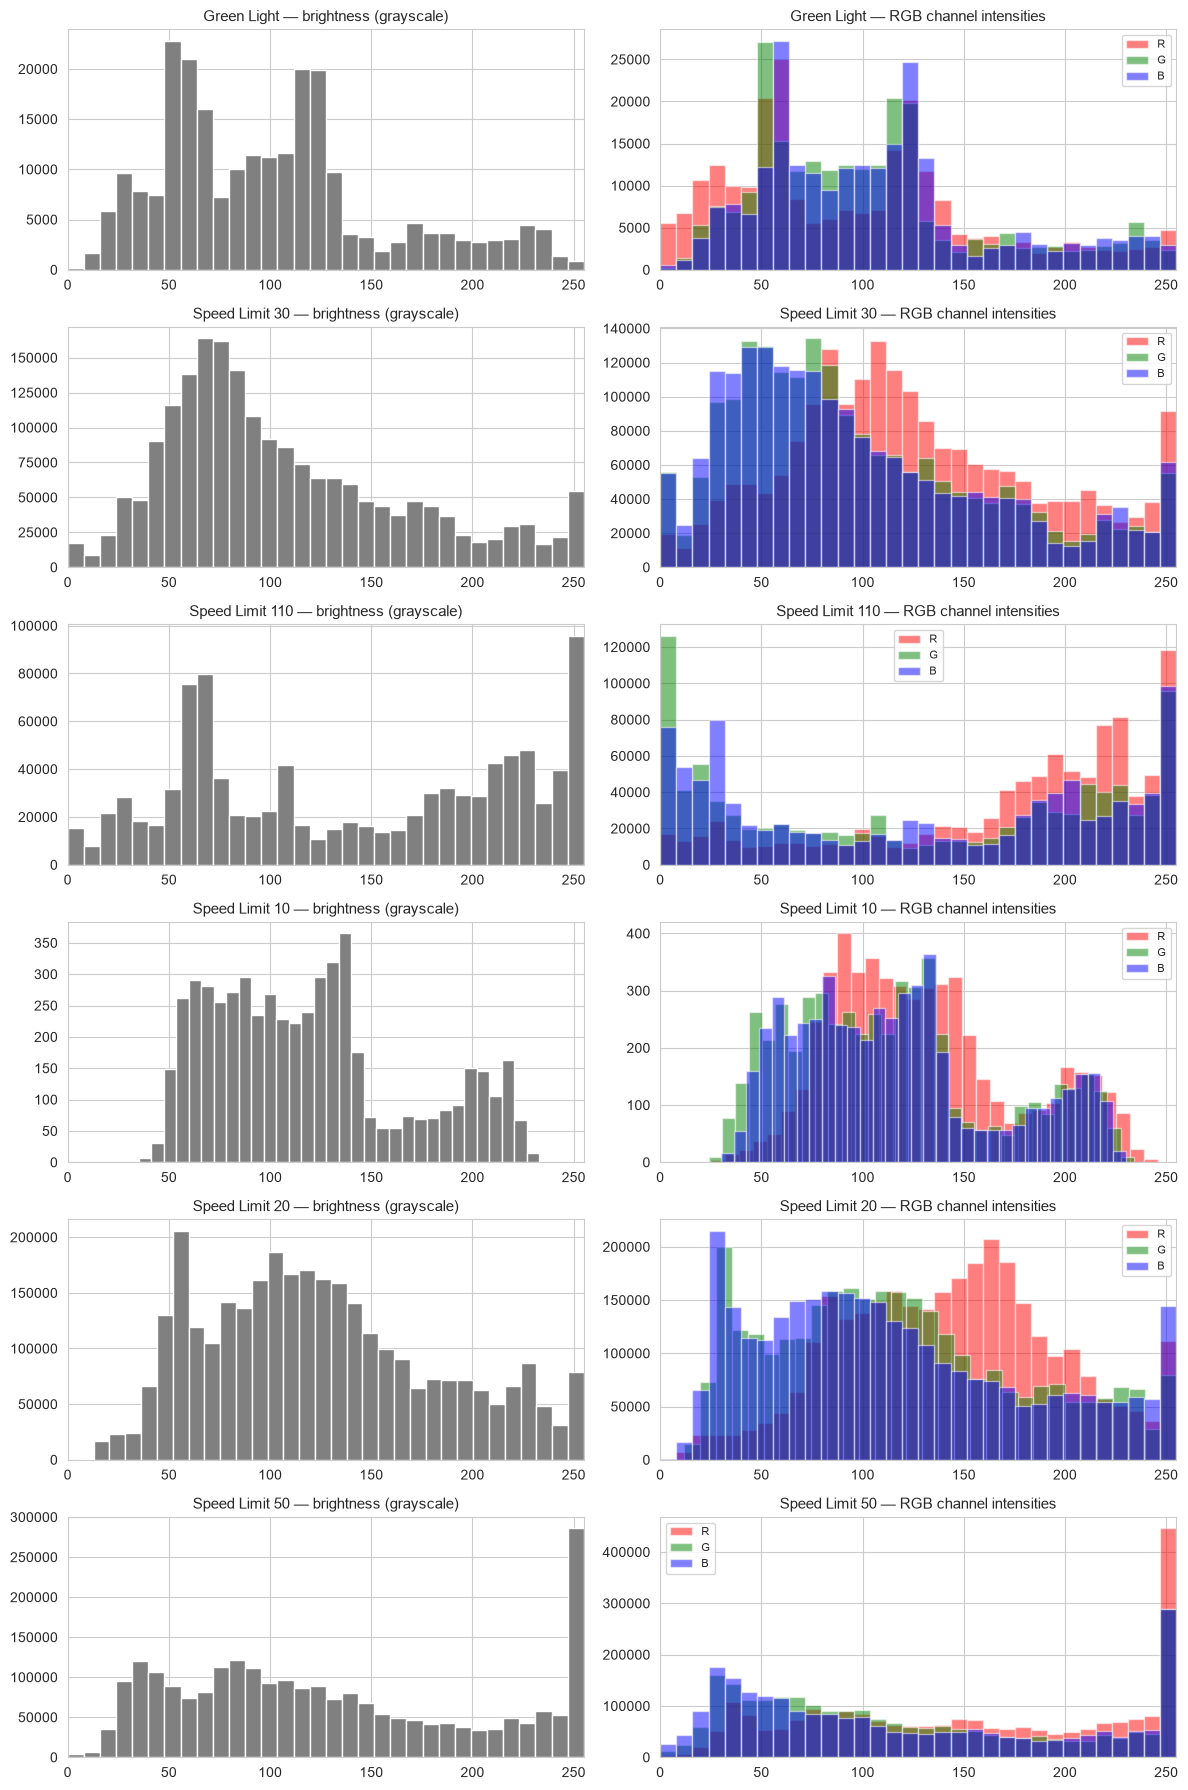

In [29]:
SAMPLE_N_FOR_HIST = 40

fig, axes = plt.subplots(len(rep_classes), 2, figsize=(12, 3 * len(rep_classes)))
if len(rep_classes) == 1:
    axes = axes.reshape(1, -1)

for i, cname in enumerate(rep_classes):
    rows = clean_instances_df[clean_instances_df["class_name"] == cname]
    rows = rows.sample(min(SAMPLE_N_FOR_HIST, len(rows)), random_state=RANDOM_STATE)

    gray_pixels, r_pixels, g_pixels, b_pixels = [], [], [], []
    for _, r in rows.iterrows():
        crop = crop_instance(r["image_path"], r["x_center"], r["y_center"],
                              r["bbox_width"], r["bbox_height"], r["img_width"], r["img_height"])
        if crop is None:
            continue
        arr = np.array(crop.convert("RGB"))
        gray_pixels.append(np.array(crop.convert("L")).ravel())
        r_pixels.append(arr[:, :, 0].ravel())
        g_pixels.append(arr[:, :, 1].ravel())
        b_pixels.append(arr[:, :, 2].ravel())

    gray_pixels = np.concatenate(gray_pixels)
    axes[i, 0].hist(gray_pixels, bins=32, color="gray")
    axes[i, 0].set_title(f"{cname} — brightness (grayscale)")
    axes[i, 0].set_xlim(0, 255)

    axes[i, 1].hist(np.concatenate(r_pixels), bins=32, color="red", alpha=0.5, label="R")
    axes[i, 1].hist(np.concatenate(g_pixels), bins=32, color="green", alpha=0.5, label="G")
    axes[i, 1].hist(np.concatenate(b_pixels), bins=32, color="blue", alpha=0.5, label="B")
    axes[i, 1].set_title(f"{cname} — RGB channel intensities")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()


**Interpretation:** Traffic-light classes typically show a bimodal brightness histogram (a bright,
saturated colored region against a dark housing/background), while speed-limit and stop signs show
a high concentration near the bright end (white sign background) with a smaller dark cluster from
the printed digits/text and red border. This difference in brightness/color distribution across
classes suggests that per-channel normalization (e.g. scaling to [0,1] and standardizing with the
dataset's own channel mean/std) is preferable to a single global brightness threshold, and that
color information (not just grayscale shape) is a useful signal for the CNN to keep — RGB input is
recommended over converting to grayscale.


## 10. Mean Image Per Class

Every valid crop is resized to the target resolution chosen in Section 7, normalized to [0,1], and
averaged per class. Split across two figures for readability.


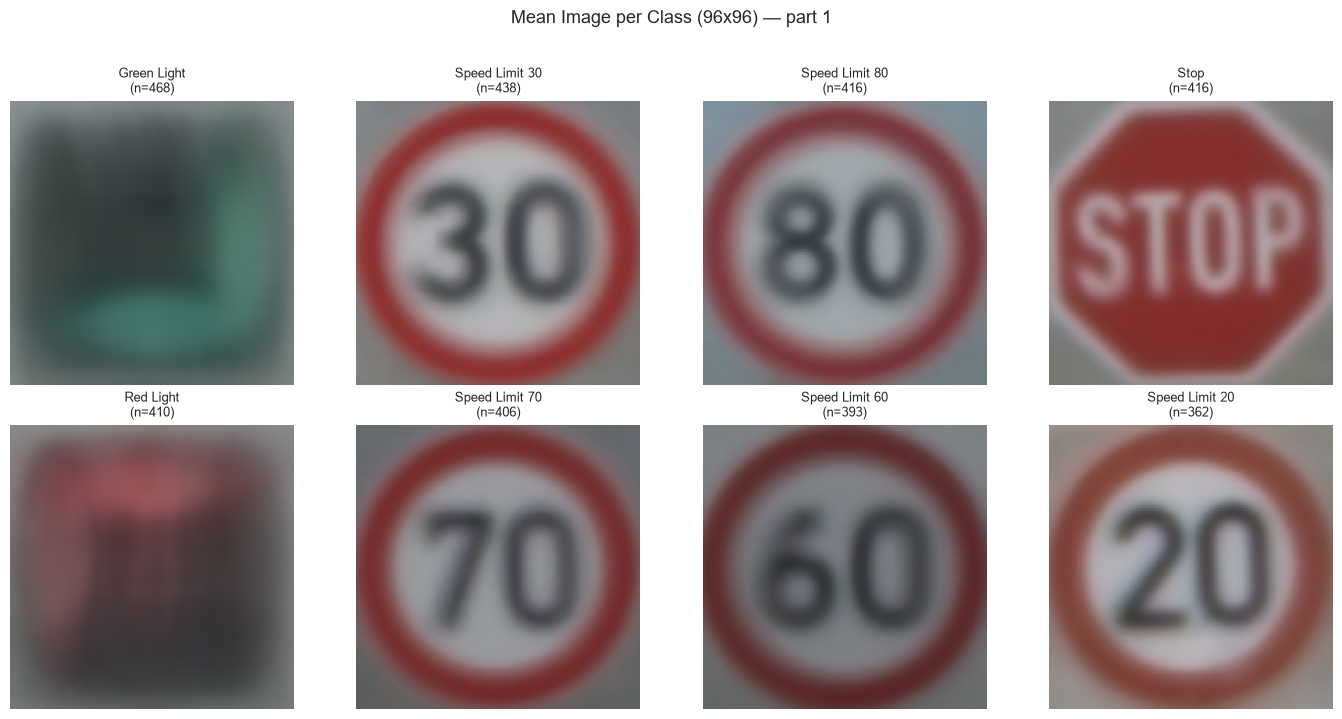

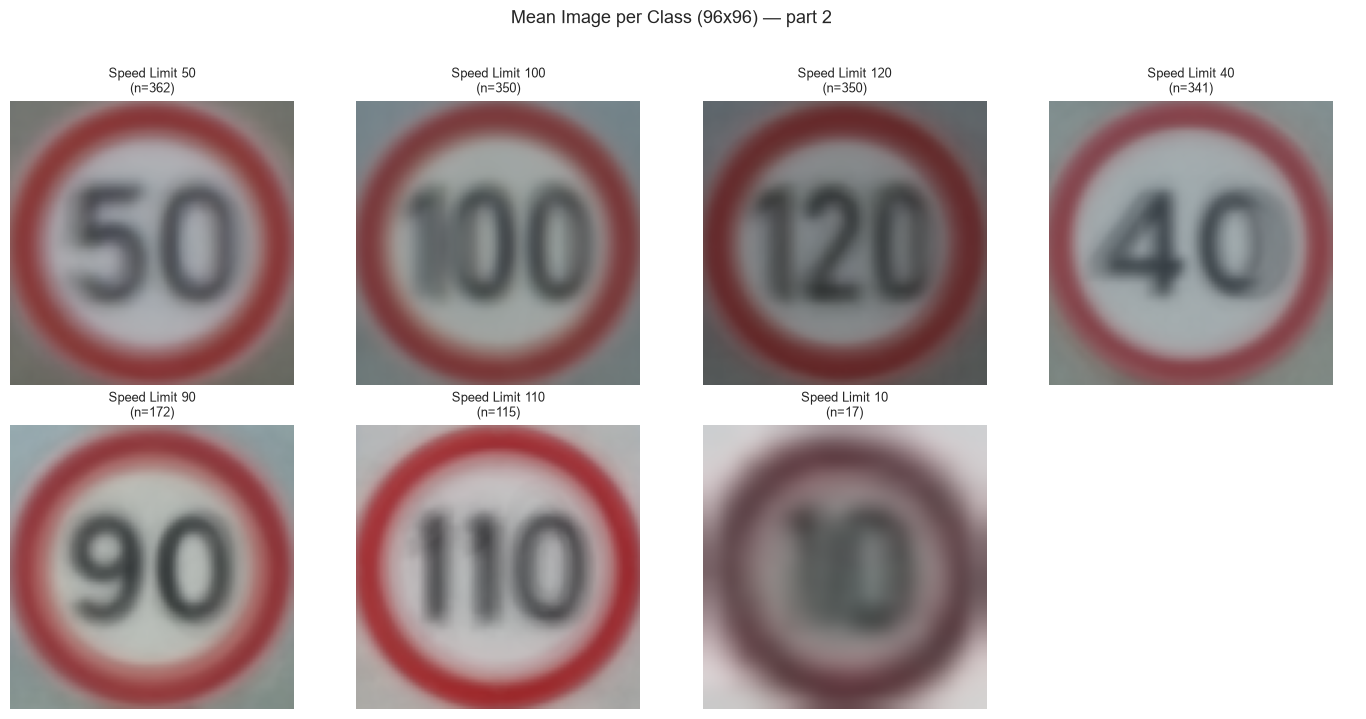

In [30]:
def compute_mean_image(class_name, target_size):
    rows = clean_instances_df[clean_instances_df["class_name"] == class_name]
    acc = np.zeros((target_size, target_size, 3), dtype=np.float64)
    n = 0
    for _, r in rows.iterrows():
        crop = crop_instance(r["image_path"], r["x_center"], r["y_center"],
                              r["bbox_width"], r["bbox_height"], r["img_width"], r["img_height"])
        if crop is None:
            continue
        resized = crop.convert("RGB").resize((target_size, target_size))
        acc += np.asarray(resized, dtype=np.float64) / 255.0
        n += 1
    if n == 0:
        return None, 0
    return acc / n, n


mean_images, mean_titles = [], []
for cname in class_order:
    mean_img, n_used = compute_mean_image(cname, TARGET_SIZE)
    if mean_img is not None:
        mean_images.append(mean_img)
        mean_titles.append(f"{cname}\n(n={n_used})")

CLASSES_PER_MEAN_FIGURE = 8
for start in range(0, len(mean_images), CLASSES_PER_MEAN_FIGURE):
    plot_sample_grid(
        mean_images[start:start + CLASSES_PER_MEAN_FIGURE],
        mean_titles[start:start + CLASSES_PER_MEAN_FIGURE],
        ncols=4, figsize=(14, 7),
        suptitle=f"Mean Image per Class ({TARGET_SIZE}x{TARGET_SIZE}) — part {start // CLASSES_PER_MEAN_FIGURE + 1}",
    )


**Interpretation:** The mean images make the shared visual template within each sign family
obvious: the speed-limit classes all average out to the same circular red-bordered, white-filled
disc shape, because that part of the sign is geometrically consistent across every image of that
class — only the faint, blurred digits near the center differ from class to class after averaging.
This is strong visual evidence that the *outer shape and color* of a speed-limit sign is **not**
enough to tell the classes apart; the CNN must learn to resolve the fine detail in the small central
digit region, which is exactly why Finding 2 (choosing a target resolution that preserves detail)
and Finding 1 (protecting the rarest classes from being drowned out) both matter for this dataset.
The Stop sign's mean image keeps a distinct octagonal silhouette, and the two light classes keep
their distinct dominant color (green vs red) even after averaging, so those classes are less likely
to be confused with the speed-limit family.


## Summary of Recommendations for Model Design

1. **Preprocessing pipeline:** crop each annotated bounding box out of its source image, drop boxes
   under 8px on a side, convert to RGB, resize to the target resolution chosen in Section 7, and
   normalize pixel values (e.g. to [0,1] or standardized with dataset channel mean/std).
2. **Target input resolution:** chosen data-drivenly from the crop-size distribution in Section 7
   (printed above as `TARGET_SIZE`), not assumed in advance.
3. **Class imbalance:** use class-weighted loss and/or oversampling/augmentation targeted at the
   rarest class(es) identified in Section 4/Finding 1, and report per-class metrics.
4. **Split strategy:** stratified 70% train / 15% validation / 15% test on the instance-level
   (cropped) data, as demonstrated in Section 5, to keep each class proportionally represented in
   every split.
5. **Data quality:** remove/flag any corrupt files, duplicate images (especially any crossing a
   split boundary), and degenerate bounding boxes found in Section 3 before training.

This notebook performs EDA only — no model was trained.
